In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task 2 Possession - Pramisha Shrestha
What was the average possession percentage of FIFA World Cup 2026 teams, and did teams that won their matches have significantly higher possession than teams that lost?

This question matters because possession is often assumed to be a strong predictor of
success in football. Testing it directly against real tournament data lets us check
whether that assumption holds up statistically, rather than relying on commentary or anecdote.

In [44]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [45]:
# Import the dataset
df2 = pd.read_csv("/content/drive/MyDrive/task2_possession.csv")
df2.head()

,Squad,Result,Poss,Opponent
0,Ghana,W,38,pa Panama
1,Ghana,D,21,eng England
2,Ghana,L,47,hr Croatia
3,Ghana,L,39,co Colombia
4,Spain,D,74,cv Cabo Verde


### Data Wrangling

The possession dataset was manually compiled from fbref.com, since no single "all-teams"
match-level possession table exists on the site. For each of 11 selected teams (chosen to
include both deep tournament runs and early group-stage exits, to avoid sampling bias toward
only successful teams), the following steps were carried out:

1. Located each team's individual "Scores & Fixtures" page on fbref.com.
2. Filtered the match log to official 2026 FIFA World Cup matches only, excluding qualifiers
   and friendlies that appear on the same page.
3. Extracted the Result (Win/Draw/Loss) and Poss (possession %) for each match.
4. Combined all 11 teams into a single dataset, adding a Squad column to identify which team
   each match performance belonged to.
5. Cross-checked and corrected team labels against known match outcomes before finalising
   the dataset (task2_possession.csv).

This process converted 11 separately formatted team pages into one clean, analysis-ready
table containing 52 team-match observations.

In [46]:
# Inspect the raw data before wrangling
print("Shape:", df2.shape)
print("\nData types:\n", df2.dtypes)
print("\nMissing values:\n", df2.isnull().sum())
print("\nUnique Result values:", df2['Result'].unique())
print("\nUnique Squad count:", df2['Squad'].nunique())

# Wrangling: ensure Poss is numeric (it may load as text/object from CSV)
df2['Poss'] = pd.to_numeric(df2['Poss'], errors='coerce')

# Wrangling: standardise Result values (strip whitespace, uppercase)
df2['Result'] = df2['Result'].str.strip().str.upper()

# Confirm the wrangled dataset is clean
print("\nAfter wrangling — dtypes:\n", df2.dtypes)
print("Any remaining nulls in Poss:", df2['Poss'].isnull().sum())
df2.head()

Shape: (52, 4)

Data types:
 Squad       object
Result      object
Poss         int64
Opponent    object
dtype: object

Missing values:
 Squad       0
Result      0
Poss        0
Opponent    0
dtype: int64

Unique Result values: ['W' 'D' 'L']

Unique Squad count: 11

After wrangling — dtypes:
 Squad       object
Result      object
Poss         int64
Opponent    object
dtype: object
Any remaining nulls in Poss: 0


,Squad,Result,Poss,Opponent
0,Ghana,W,38,pa Panama
1,Ghana,D,21,eng England
2,Ghana,L,47,hr Croatia
3,Ghana,L,39,co Colombia
4,Spain,D,74,cv Cabo Verde


Data preparation and sampling

In [47]:
# Population: all team-match possession performances at the World Cup 2026
# Sample: 52 team-match performances across 11 teams, mixing deep-run and early-exit teams
# to avoid sampling bias. Keep only Win/Loss for the two-group comparison (Draws excluded, n=11).
sample2 = df2[df2['Result'].isin(['W', 'L'])].copy()
sample2['Poss'] = sample2['Poss'].astype(float)

wins = sample2[sample2['Result'] == 'W']['Poss']
losses = sample2[sample2['Result'] == 'L']['Poss']

print(f"Sample size (Win + Loss): n = {len(sample2)}")
print(f"  Wins:   n = {len(wins)}")
print(f"  Losses: n = {len(losses)}")

Sample size (Win + Loss): n = 41
  Wins:   n = 25
  Losses: n = 16


Descriptive statistics

In [48]:
def describe(s, label):
    print(f"-- {label} (n={len(s)}) --")
    print(f"Mean:   {s.mean():.2f}%")
    print(f"Median: {s.median():.2f}%")
    print(f"Std:    {s.std():.2f}")
    print(f"Min/Max: {s.min():.1f} / {s.max():.1f}\n")

describe(sample2['Poss'], "All Win/Loss performances")
describe(wins, "Winning performances")
describe(losses, "Losing performances")

-- All Win/Loss performances (n=41) --
Mean:   50.76%
Median: 52.00%
Std:    13.16
Min/Max: 27.0 / 73.0

-- Winning performances (n=25) --
Mean:   58.20%
Median: 59.00%
Std:    9.85
Min/Max: 33.0 / 73.0

-- Losing performances (n=16) --
Mean:   39.12%
Median: 38.00%
Std:    8.37
Min/Max: 27.0 / 62.0



Confidence interval

In [49]:
def confidence_interval(x, confidence=0.95):
    n = len(x)
    mean = np.mean(x)
    sem = stats.sem(x)
    margin = sem * stats.t.ppf((1 + confidence) / 2, df=n - 1)
    return mean, mean - margin, mean + margin

mean_p, lo, hi = confidence_interval(sample2['Poss'])
print(f"Sample mean possession = {mean_p:.2f}%")
print(f"95% Confidence Interval = ({lo:.2f}%, {hi:.2f}%)")
print(f"We are 95% confident the true mean possession across all World Cup 2026")
print(f"team-match performances lies between {lo:.2f}% and {hi:.2f}%.")

Sample mean possession = 50.76%
95% Confidence Interval = (46.60%, 54.91%)
We are 95% confident the true mean possession across all World Cup 2026
team-match performances lies between 46.60% and 54.91%.


Two-sample t-test

In [50]:
# H0: mean possession (Wins) = mean possession (Losses)
# H1: mean possession (Wins) != mean possession (Losses)
t_stat, p_value = stats.ttest_ind(wins, losses, equal_var=False)

print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\np < {alpha} -> Reject H0. Significant difference in possession between wins and losses.")
else:
    print(f"\np >= {alpha} -> Fail to reject H0. No significant difference found.")

t-statistic = 6.635
p-value     = 0.000000

p < 0.05 -> Reject H0. Significant difference in possession between wins and losses.


Visualization and conclusion

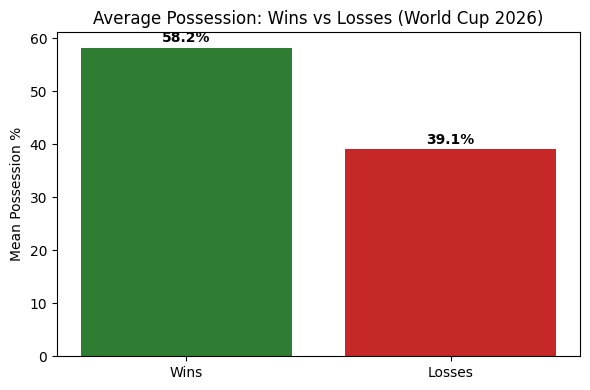

In [51]:
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Wins', 'Losses'], [wins.mean(), losses.mean()], color=['#2e7d32', '#c62828'])
ax.set_ylabel('Mean Possession %')
ax.set_title('Average Possession: Wins vs Losses (World Cup 2026)')
for i, v in enumerate([wins.mean(), losses.mean()]):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusion:** Winning performances averaged 58.2% possession versus 39.1% for losing performances.
The 95% CI for overall mean possession was (46.6%, 54.9%). The two-sample t-test showed this
difference is statistically significant (p < 0.0001).

**Limitation:** This is correlational, not causal, higher possession may partly reflect already
being ahead in a match rather than possession itself causing the win.